UNET EVALUATION AND VISUALIZATION NOTEBOOK

In [4]:
import os
import torch
import sys
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from torch.utils.data import DataLoader

In [5]:
p = Path.cwd().resolve()
repo_root = next(parent for parent in [p, *p.parents] if (parent / "scripts").exists())
sys.path.insert(0, str(repo_root / "scripts"))

In [6]:
from voc_datasets import (
    build_voc_datasets,
    VOC_CLASSES,
    NUM_CLASSES,
    IGNORE_INDEX,
)

from unet import UNet
from losses import get_ce_loss
from metrics import (
    logits_to_preds,
    compute_pixel_accuracy,
    compute_mean_iou,
    compute_mean_dice,
    compute_per_class_iou,
    compute_per_class_dice,
    compute_per_class_accuracy,
    compute_confusion_matrix,
)
from train_utils import validate_one_epoch

In [7]:
#CONFIG
ROOT = r"c:/Users/Kwame Boateng/Documents/GitHub/semantic-segmentation/Data"
IMG_SIZE = 256
BATCH_SIZE = 8
NUM_WORKERS = 2

CHECKPOINT_PATH = "checkpoints/unet_best.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [8]:
#DATASET AND LOADER
train_dataset, val_dataset = build_voc_datasets(
    root=ROOT,
    img_size=IMG_SIZE
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Validation samples:", len(val_dataset))

c:\Users\Kwame Boateng\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Validation samples: 213


In [9]:
#LOAD MODEL
model = UNet(in_channels=3, num_classes=NUM_CLASSES).to(device)
criterion = get_ce_loss(ignore_index=IGNORE_INDEX)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

print("Loaded checkpoint from epoch:", checkpoint["epoch"] + 1)
print("Stored metrics:", checkpoint["metrics"])

Loaded checkpoint from epoch: 35
Stored metrics: {'loss': 1.203124420743593, 'pixel_acc': 0.7310894699723508, 'mean_iou': 0.0980916657778019, 'mean_dice': 0.12011172094255546}


In [10]:
#EVAL METRICS
val_metrics = validate_one_epoch(
    model=model,
    dataloader=val_loader,
    criterion=criterion,
    device=device,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
)

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}")

Validation metrics:
loss: 1.2031
pixel_acc: 0.7311
mean_iou: 0.0981
mean_dice: 0.1201


In [11]:
def show_prediction(image, true_mask, pred_mask, class_names, ignore_index=255):
    image = image.permute(1, 2, 0).cpu().numpy()

    true_mask = true_mask.cpu().numpy().copy()
    pred_mask = pred_mask.cpu().numpy().copy()

    true_mask_vis = true_mask.copy()
    pred_mask_vis = pred_mask.copy()

    true_mask_vis[true_mask_vis == ignore_index] = 0

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    im1 = plt.imshow(true_mask_vis, cmap="tab20", vmin=0, vmax=len(class_names) - 1)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    im2 = plt.imshow(pred_mask_vis, cmap="tab20", vmin=0, vmax=len(class_names) - 1)
    plt.title("Prediction")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

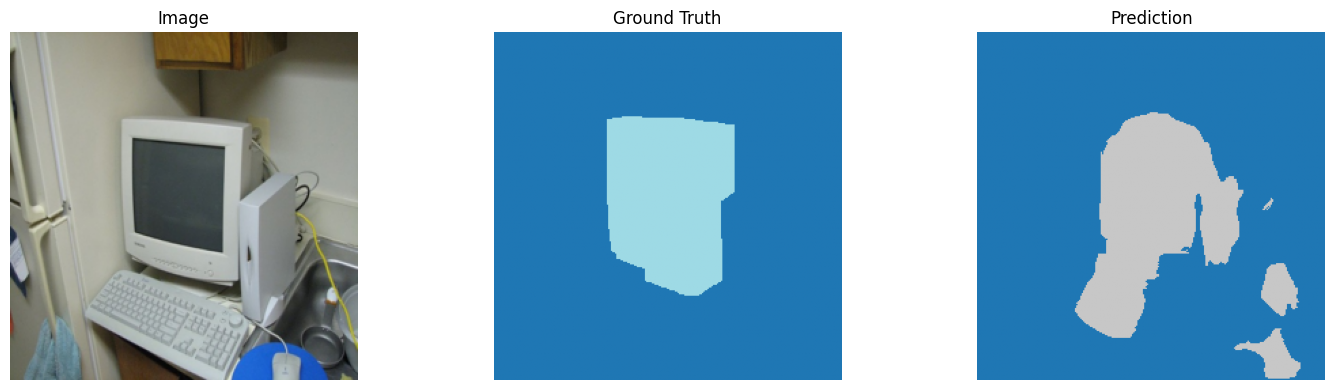

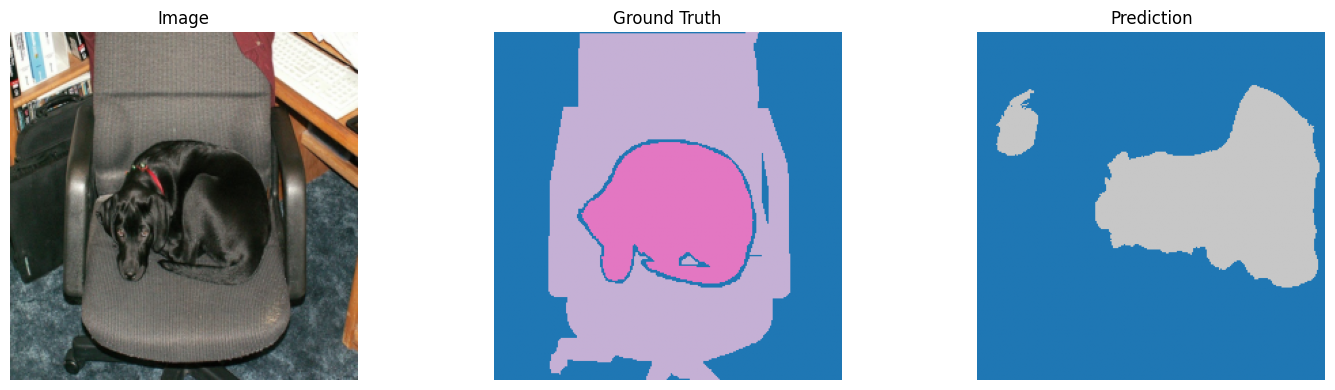

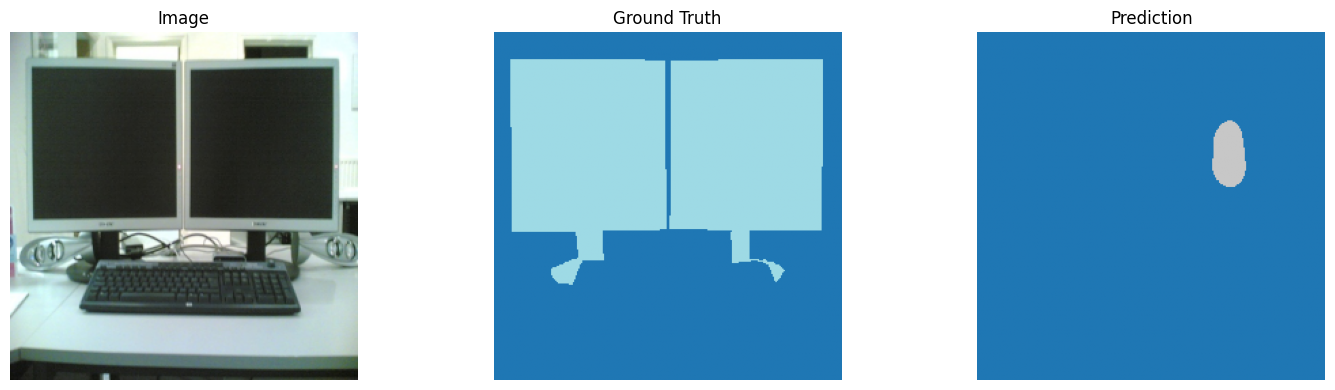

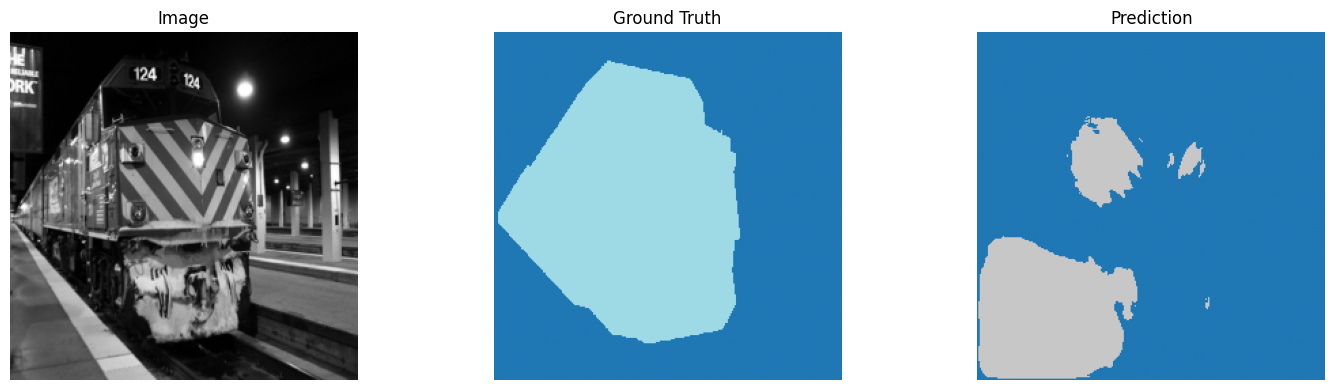

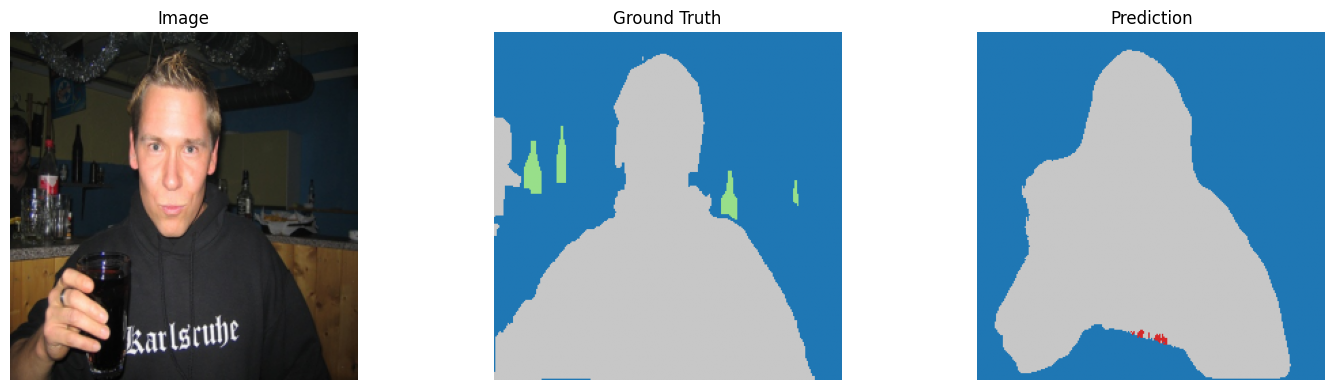

In [12]:
#SHOW PREDICTIONS
model.eval()

num_examples = 5
shown = 0

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        preds = logits_to_preds(logits)

        for i in range(images.size(0)):
            show_prediction(images[i], masks[i], preds[i], VOC_CLASSES, IGNORE_INDEX)
            shown += 1
            if shown >= num_examples:
                break

        if shown >= num_examples:
            break

In [13]:
model.eval()

all_preds = []
all_targets = []
all_images = []

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        preds = logits_to_preds(logits)

        all_preds.append(preds.cpu())
        all_targets.append(masks.cpu())
        all_images.append(images.cpu())

all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)
all_images = torch.cat(all_images, dim=0)

print("all_preds shape:", all_preds.shape)
print("all_targets shape:", all_targets.shape)
print("all_images shape:", all_images.shape)

all_preds shape: torch.Size([213, 256, 256])
all_targets shape: torch.Size([213, 256, 256])
all_images shape: torch.Size([213, 3, 256, 256])


In [14]:
#PER CLASS METRICS
per_class_iou = compute_per_class_iou(
    all_preds,
    all_targets,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
)

per_class_dice = compute_per_class_dice(
    all_preds,
    all_targets,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
)

per_class_acc = compute_per_class_accuracy(
    all_preds,
    all_targets,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
)

print(f"{'Class':<15} {'IoU':>10} {'Dice':>10} {'Acc':>10}")
for i, name in enumerate(VOC_CLASSES):
    iou = per_class_iou[i].item() if not torch.isnan(per_class_iou[i]) else float("nan")
    dice = per_class_dice[i].item() if not torch.isnan(per_class_dice[i]) else float("nan")
    acc = per_class_acc[i].item() if not torch.isnan(per_class_acc[i]) else float("nan")
    print(f"{name:<15} {iou:>10.4f} {dice:>10.4f} {acc:>10.4f}")

Class                  IoU       Dice        Acc
background          0.7637     0.8660     0.9426
aeroplane           0.0000     0.0000     0.0000
bicycle             0.0000     0.0000     0.0000
bird                0.0000     0.0000     0.0000
boat                0.0000     0.0000     0.0000
bottle              0.0000     0.0000     0.0000
bus                 0.0197     0.0387     0.0217
car                 0.0000     0.0000     0.0000
cat                 0.0000     0.0000     0.0000
chair               0.0000     0.0000     0.0000
cow                 0.0000     0.0000     0.0000
diningtable         0.0000     0.0000     0.0000
dog                 0.0000     0.0000     0.0000
horse               0.0000     0.0000     0.0000
motorbike           0.0000     0.0000     0.0000
person              0.2317     0.3762     0.5968
pottedplant         0.0000     0.0000     0.0000
sheep               0.0000     0.0000     0.0000
sofa                0.0000     0.0000     0.0000
train               

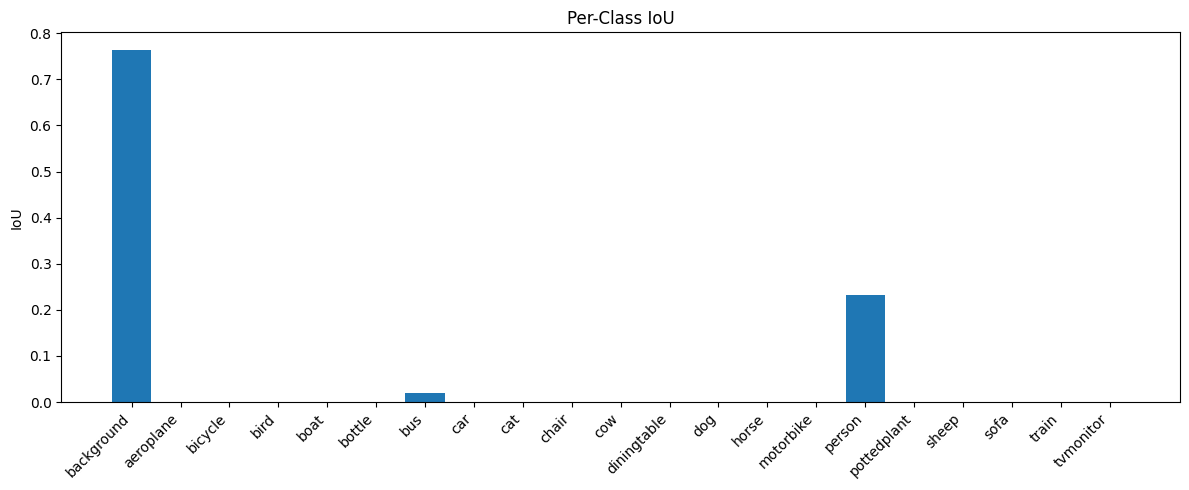

In [15]:
#PER CLASS IOU METRIC
iou_values = per_class_iou.cpu().numpy()

plt.figure(figsize=(12, 5))
plt.bar(range(NUM_CLASSES), np.nan_to_num(iou_values, nan=0.0))
plt.xticks(range(NUM_CLASSES), VOC_CLASSES, rotation=45, ha="right")
plt.ylabel("IoU")
plt.title("Per-Class IoU")
plt.tight_layout()
plt.show()

In [16]:
#CONFUSION MATRIX
cm = compute_confusion_matrix(
    all_preds,
    all_targets,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
)

print("Confusion matrix shape:", cm.shape)
cm

Confusion matrix shape: torch.Size([21, 21])


tensor([[9246587,       0,       0,       0,       0,       0,    8217,       0,
               0,       0,       0,       0,       0,       0,       0,  555316,
               0,       0,       0,       0,       0],
        [  87644,       0,       0,       0,       0,       0,      70,       0,
               0,       0,       0,       0,       0,       0,       0,   33568,
               0,       0,       0,       0,       0],
        [  19021,       0,       0,       0,       0,       0,       0,       0,
               0,       0,       0,       0,       0,       0,       0,    9746,
               0,       0,       0,       0,       0],
        [  73322,       0,       0,       0,       0,       0,      26,       0,
               0,       0,       0,       0,       0,       0,       0,   53089,
               0,       0,       0,       0,       0],
        [  52852,       0,       0,       0,       0,       0,    4425,       0,
               0,       0,       0,       0,       

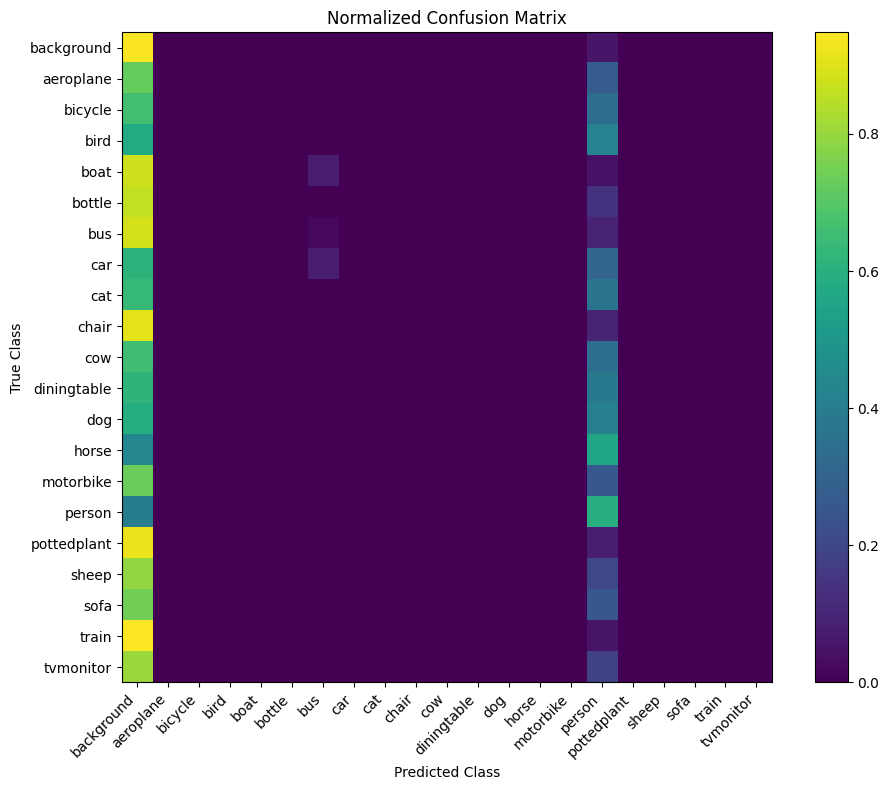

In [17]:
cm_np = cm.cpu().numpy().astype(np.float64)
row_sums = cm_np.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm_np, row_sums, where=row_sums != 0)

plt.figure(figsize=(10, 8))
plt.imshow(cm_norm, interpolation="nearest")
plt.title("Normalized Confusion Matrix")
plt.colorbar()
plt.xticks(range(NUM_CLASSES), VOC_CLASSES, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), VOC_CLASSES)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()

In [18]:
def compute_sample_iou(pred_mask, true_mask, num_classes, ignore_index=255):
    return compute_mean_iou(
        pred_mask.unsqueeze(0),
        true_mask.unsqueeze(0),
        num_classes=num_classes,
        ignore_index=ignore_index,
    )

def compute_sample_dice(pred_mask, true_mask, num_classes, ignore_index=255):
    return compute_mean_dice(
        pred_mask.unsqueeze(0),
        true_mask.unsqueeze(0),
        num_classes=num_classes,
        ignore_index=ignore_index,
    )

sample_scores = []

for i in range(len(all_preds)):
    miou = compute_sample_iou(all_preds[i], all_targets[i], NUM_CLASSES, IGNORE_INDEX)
    mdice = compute_sample_dice(all_preds[i], all_targets[i], NUM_CLASSES, IGNORE_INDEX)

    sample_scores.append({
        "index": i,
        "mean_iou": miou,
        "mean_dice": mdice,
    })

sample_scores = sorted(sample_scores, key=lambda x: x["mean_iou"], reverse=True)

print("Top sample:", sample_scores[0])
print("Worst sample:", sample_scores[-1])

Top sample: {'index': 184, 'mean_iou': 0.7873976230621338, 'mean_dice': 0.8799073696136475}
Worst sample: {'index': 15, 'mean_iou': 0.054705552756786346, 'mean_dice': 0.08976789563894272}


Best examples:
{'index': 184, 'mean_iou': 0.7873976230621338, 'mean_dice': 0.8799073696136475}


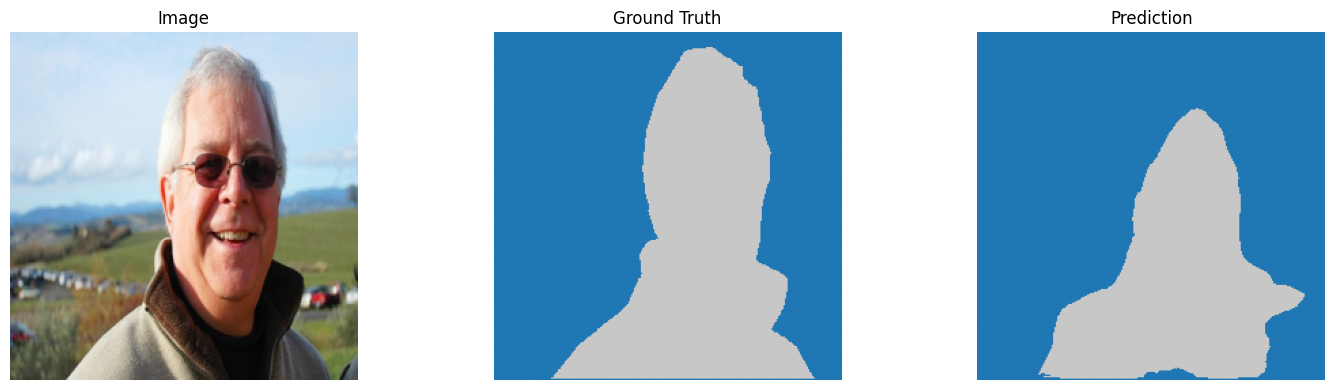

{'index': 30, 'mean_iou': 0.7604124546051025, 'mean_dice': 0.8639023900032043}


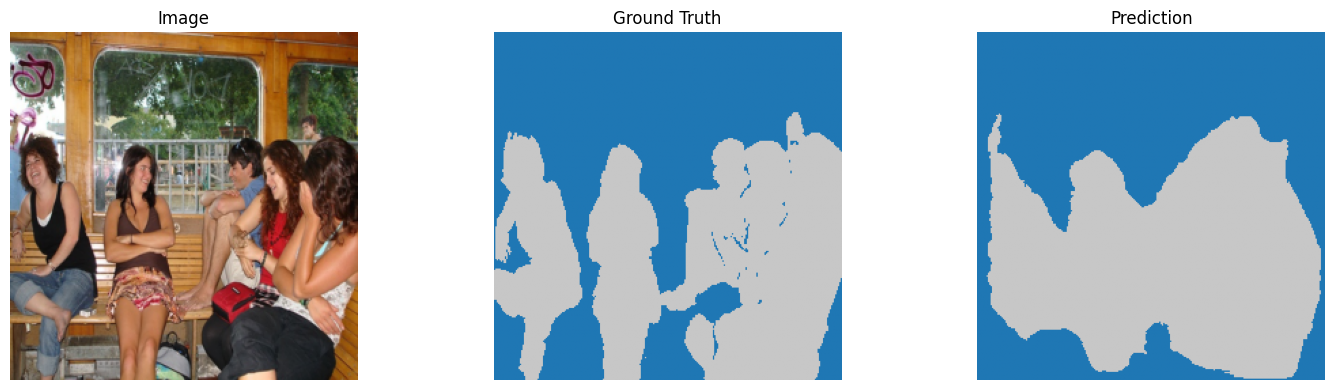

{'index': 77, 'mean_iou': 0.6758387088775635, 'mean_dice': 0.8016421794891357}


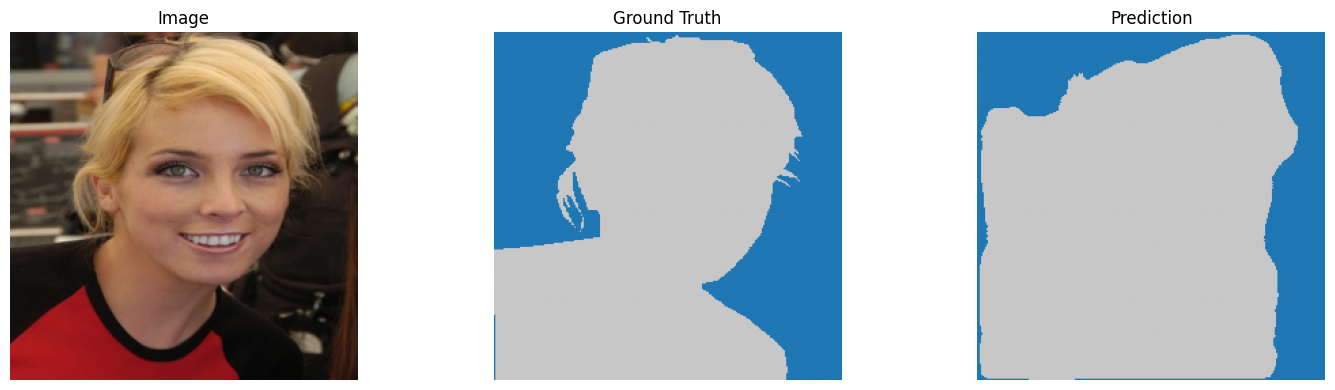

In [19]:
#SHOW BEST EXAMPLE
top_k = 3

print("Best examples:")
for entry in sample_scores[:top_k]:
    idx = entry["index"]
    print(entry)
    show_prediction(all_images[idx], all_targets[idx], all_preds[idx], VOC_CLASSES, IGNORE_INDEX)

Worst examples:
{'index': 49, 'mean_iou': 0.0913776308298111, 'mean_dice': 0.12544220685958862}


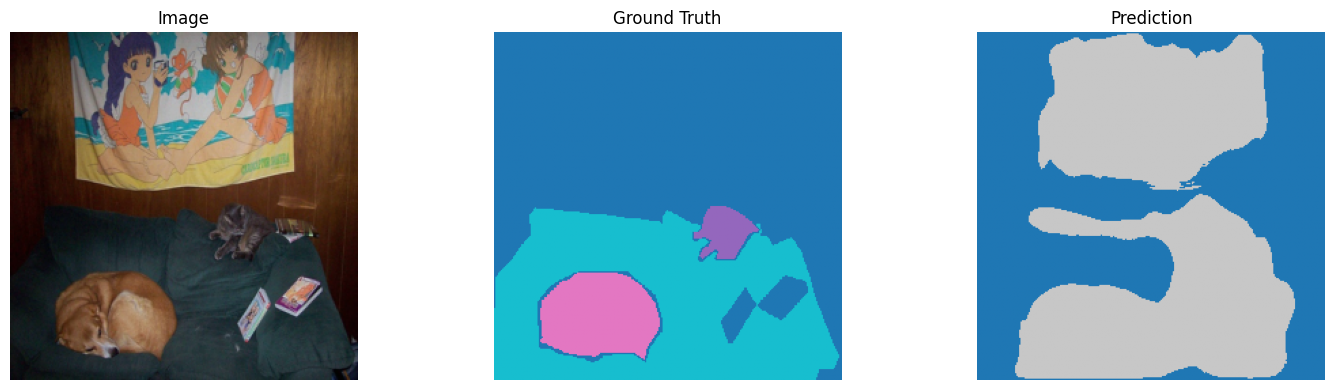

{'index': 212, 'mean_iou': 0.05641378089785576, 'mean_dice': 0.09649638086557388}


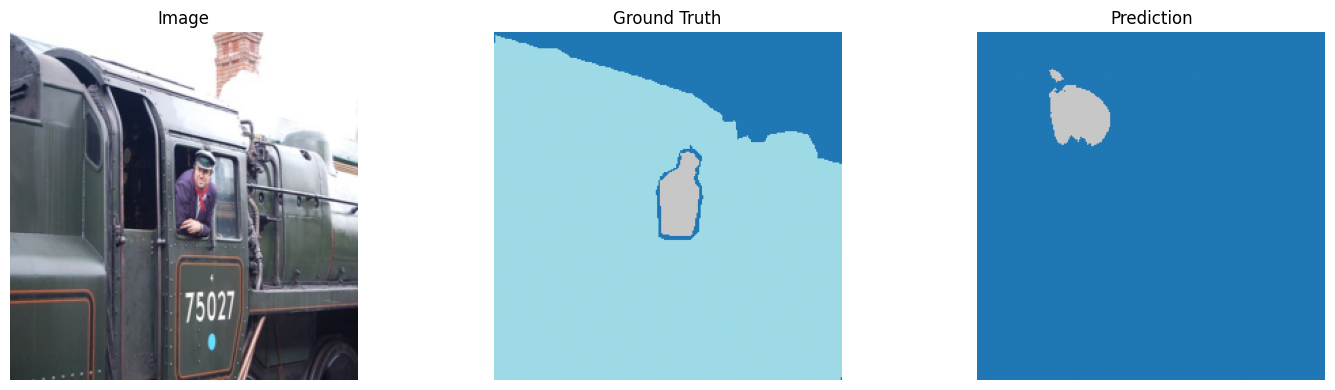

{'index': 15, 'mean_iou': 0.054705552756786346, 'mean_dice': 0.08976789563894272}


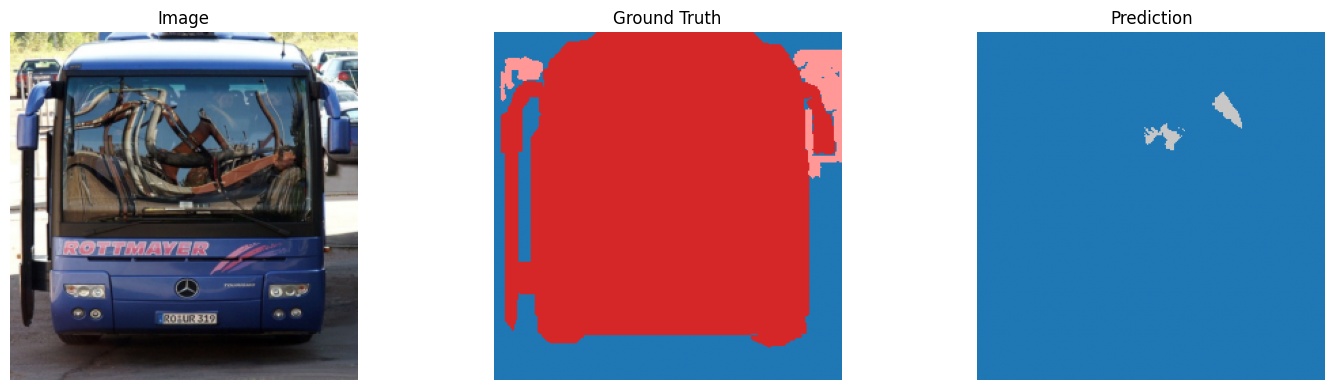

In [20]:
#SHOW WORST EXAMPLE
top_k = 3

print("Worst examples:")
for entry in sample_scores[-top_k:]:
    idx = entry["index"]
    print(entry)
    show_prediction(all_images[idx], all_targets[idx], all_preds[idx], VOC_CLASSES, IGNORE_INDEX)

In [21]:
#SUMMARY
overall_pixel_acc = compute_pixel_accuracy(all_preds, all_targets, IGNORE_INDEX)
overall_miou = compute_mean_iou(all_preds, all_targets, NUM_CLASSES, IGNORE_INDEX)
overall_mdice = compute_mean_dice(all_preds, all_targets, NUM_CLASSES, IGNORE_INDEX)

print("U-Net Final Evaluation Summary")
print(f"Pixel Accuracy: {overall_pixel_acc:.4f}")
print(f"Mean IoU: {overall_miou:.4f}")
print(f"Mean Dice: {overall_mdice:.4f}")

U-Net Final Evaluation Summary
Pixel Accuracy: 0.7316
Mean IoU: 0.0483
Mean Dice: 0.0610


In [22]:
#HD95
from metrics import compute_hd95

per_class_hd95 = compute_hd95(
    all_preds,
    all_targets,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
)

print(f"{'Class':<15} {'HD95':>10}")
for i, name in enumerate(VOC_CLASSES):
    value = per_class_hd95[i].item() if not torch.isnan(per_class_hd95[i]) else float("nan")
    print(f"{name:<15} {value:>10.4f}")

Class                 HD95
background         24.9333
aeroplane              nan
bicycle                nan
bird                   nan
boat                   nan
bottle                 nan
bus                72.8776
car                    nan
cat                    nan
chair                  nan
cow                    nan
diningtable            nan
dog                    nan
horse                  nan
motorbike              nan
person             82.1921
pottedplant            nan
sheep                  nan
sofa                   nan
train                  nan
tvmonitor              nan
